In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("/content/train.csv")

In [7]:
df.head()

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [8]:
df.shape

(18000, 17)

**List of all columns**

In [9]:
columns = list(df.columns)
columns

['id',
 'date',
 'region',
 'channel',
 'product_category',
 'customer_segment',
 'ad_spend',
 'price',
 'discount_rate',
 'market_reach',
 'impressions',
 'click_through_rate',
 'competition_index',
 'seasonality_index',
 'campaign_duration_days',
 'customer_lifetime_value',
 'sales_revenue']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       18000 non-null  int64  
 1   date                     18000 non-null  object 
 2   region                   18000 non-null  object 
 3   channel                  18000 non-null  object 
 4   product_category         18000 non-null  object 
 5   customer_segment         18000 non-null  object 
 6   ad_spend                 17342 non-null  float64
 7   price                    18000 non-null  float64
 8   discount_rate            17245 non-null  float64
 9   market_reach             17314 non-null  float64
 10  impressions              18000 non-null  int64  
 11  click_through_rate       17287 non-null  float64
 12  competition_index        17293 non-null  float64
 13  seasonality_index        18000 non-null  float64
 14  campaign_duration_days

Categoriacal and numarical columns

In [11]:
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)
print(f'categorical variables:  {cats}')
print(f'numerical variables:  {nums}')

categorical variables:  ['date', 'region', 'channel', 'product_category', 'customer_segment']
numerical variables:  ['id', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'seasonality_index', 'campaign_duration_days', 'customer_lifetime_value', 'sales_revenue']


In [12]:
df.nunique(axis=0)

,0
id,18000
date,11926
region,10
channel,11
product_category,6
customer_segment,3
ad_spend,1207
price,474
discount_rate,5125
market_reach,527


As there are few unique values for campaign_duration_days and seasonality_index is easily to make them categorical instead of numeric

In [12]:
cats.extend(['seasonality_index', 'campaign_duration_days'])
nums.remove('seasonality_index')
nums.remove('campaign_duration_days')

print(f'Updated categorical: {cats}')
print(f'Updated numerical: {nums}')

Updated categorical: ['date', 'region', 'channel', 'product_category', 'customer_segment', 'seasonality_index', 'campaign_duration_days']
Updated numerical: ['id', 'ad_spend', 'price', 'discount_rate', 'market_reach', 'impressions', 'click_through_rate', 'competition_index', 'customer_lifetime_value', 'sales_revenue']


In [14]:
df.isna().sum()

,0
id,0
date,0
region,0
channel,0
product_category,0
customer_segment,0
ad_spend,658
price,0
discount_rate,755
market_reach,686


In [15]:
df[df.isnull().any(axis=1)]

,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
8,9,2010-04-28 10:02:00,North,Search,Storage,Premium,17.00,8.50,NaN,168.0,3767,0.0316,2.92,0.366025,7.0,1517.250,93.580933
9,10,2009-12-20 15:38:00,North,Affiliate,Kitchen,Premium,NaN,0.85,0.1296,266.0,8803,0.0701,0.97,1.000000,21.0,319.260,204.285671
10,11,2010-04-20 17:25:00,North,Social Media,General,Premium,6.50,0.65,0.0796,NaN,3461,0.0475,2.42,0.366025,28.0,NaN,240.785447
15,16,2010-07-05 12:49:00,North,Email,Stationery,Standard,39.00,1.95,0.3123,658.0,11825,0.0145,2.89,-1.366025,NaN,97.400,87.711493
28,29,2010-12-09 13:03:00,North,Affiliate,Storage,Premium,1.95,1.95,0.1311,450.0,12383,NaN,5.49,1.000000,14.0,1899.540,117.097701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17973,17974,2010-07-08 13:49:00,NORTH,TV,Storage,Premium,3.30,1.65,0.1148,705.0,20503,NaN,2.70,-1.366025,21.0,4636.020,112.985079
17980,17981,2011-03-15 13:13:00,East,Influencer,Kitchen,Premium,NaN,1.49,0.2227,183.0,3371,0.0149,2.96,1.000000,28.0,4257.270,146.768764
17982,17983,2011-07-07 13:35:00,North,Influencer,General,Standard,40.80,0.85,NaN,445.0,15502,0.0082,3.21,-1.366025,14.0,3891.881,157.636915
17990,17991,2011-11-20 12:11:00,North,Search,General,Standard,5.80,1.45,0.2440,483.0,13040,NaN,4.90,0.366025,21.0,1198.850,147.301152


In [13]:
10 / len(df)

0.0005555555555555556

In [14]:
df = df[~df.isnull().any(axis=1)]
df.reset_index(inplace=True)
df.drop('index', inplace=True, axis=1)
df.shape

(12984, 17)

In [15]:
print(f'total duplicate rows: {df.duplicated().sum()}')

df = df[~df.duplicated()]
df.shape

total duplicate rows: 0


(12984, 17)

Group all variables together

In [16]:
df = pd.concat((df[cats], df[nums]), axis=1)
df.head()

,date,region,channel,product_category,customer_segment,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,2011-12-05 11:31:00,Nort,Search,General,Standard,1,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2011-04-27 14:01:00,North,Social Media,General,Premium,2,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,2010-11-09 15:20:00,North,Affiliate,General,Budget,3,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,4,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,2011-10-14 09:28:00,North,Search,Lighting,Premium,5,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


In [17]:
num_rows, num_cols = df.shape

In [22]:
df.to_csv('train_cleaned.csv', index=False)

In [23]:
print(f'categorical variables:  {cats}')

categorical variables:  ['date', 'region', 'channel', 'product_category', 'customer_segment']


In [25]:
df_cat = df.loc[:, 'region':'customer_segment']
df_cat.head()

,region,channel,product_category,customer_segment
0,Nort,Search,General,Standard
1,North,Social Media,General,Premium
2,North,Affiliate,General,Budget
3,North,Affiliate,Storage,Premium
4,North,Search,Lighting,Premium


Remove extra spaces

In [26]:
text_cols = ['region', 'channel', 'product_category', 'customer_segment']
for col in text_cols:
    df_cat[col] = df_cat[col].apply(lambda x: ' '.join(str(x).split()) if pd.notnull(x) else x)


df[text_cols] = df_cat[text_cols]

In [27]:
print(df.isnull().sum())

date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
id                         0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
sales_revenue              0
dtype: int64


Handle Inconsistent Text

In [28]:
for col in text_cols:
    df[col] = df[col].str.title()
print(df['region'].unique())

['Nort' 'North' 'Central' 'Norht' 'East' 'South' 'West']


In [29]:
region_mapping = {'Nort': 'North', 'Norht': 'North'}
df['region'] = df['region'].replace(region_mapping)
print(df['region'].unique())

['North' 'Central' 'East' 'South' 'West']


In [30]:
df.describe()

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
count,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000,12984.000000
mean,8997.149415,43.475740,5.772559,0.229355,321.127696,7264.101664,0.056951,3.998082,-0.018032,35.588956,10191.290082,137.006600
std,5179.244017,186.162613,23.084999,0.149475,244.055105,7668.446016,0.049317,2.004293,0.918620,27.018066,34199.565158,54.636676
min,1.000000,0.180000,0.040000,0.000200,1.000000,-30771.000000,0.000000,0.040000,-1.366025,7.000000,0.780000,3.720168
25%,4530.750000,4.950000,1.250000,0.109375,138.000000,2513.750000,0.020400,2.420000,-1.000000,14.000000,566.745000,99.837906
50%,8971.500000,11.900000,1.950000,0.203100,266.000000,5080.000000,0.043300,3.850000,0.366025,28.000000,1774.240000,129.013704
75%,13474.250000,19.800000,3.750000,0.324300,439.000000,9560.500000,0.079700,5.420000,1.000000,60.000000,5548.540000,164.533343
max,18000.000000,2102.400000,295.000000,0.600000,1490.000000,173986.000000,0.435700,9.650000,1.366025,90.000000,543228.100000,684.320270


Visualizing sales revenue

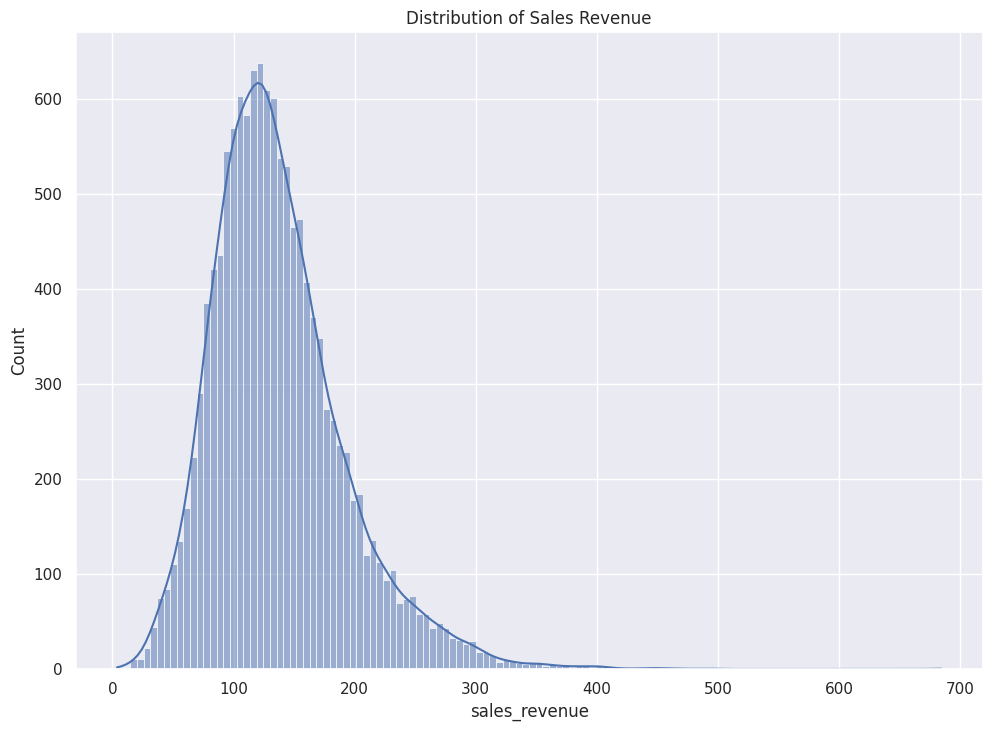

In [34]:
sns.set(rc={'figure.figsize':(11.7, 8.27)})
sns.histplot(df['sales_revenue'], kde=True)
plt.title('Distribution of Sales Revenue')
plt.show()

In [35]:
df_cat['sales_revenue'] = df['sales_revenue'].apply(lambda x: 'low' if x<109.45 else 'high' if x>149.76 else 'medium')
cats.append('sales_revenue')
print(f'categorical variables:  {cats}')

categorical variables:  ['date', 'region', 'channel', 'product_category', 'customer_segment', 'sales_revenue']


In [36]:
print(f"categories in region: {pd.unique(df_cat['region'])}")
print(f"categories in channel: {pd.unique(df_cat['channel'])}")
print(f"categories in product_category: {pd.unique(df_cat['product_category'])}")
print(f"categories in customer_segment: {pd.unique(df_cat['customer_segment'])}")


categories in region: ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'East' 'South' 'West']
categories in channel: ['Search' 'Social Media' 'Affiliate' 'Email' 'TV' 'Influencer'
 'Socail Media' 'SocialMedia' 'social media' 'Social_Media' 'social Media']
categories in product_category: ['General' 'Storage' 'Lighting' 'Stationery' 'Seasonal' 'Kitchen']
categories in customer_segment: ['Standard' 'Premium' 'Budget']


In [37]:
df_cat.describe()

,region,channel,product_category,customer_segment,sales_revenue
count,12984,12984,12984,12984,12984
unique,9,11,6,3,3
top,North,Social Media,General,Premium,high
freq,11749,3040,6478,10418,4422


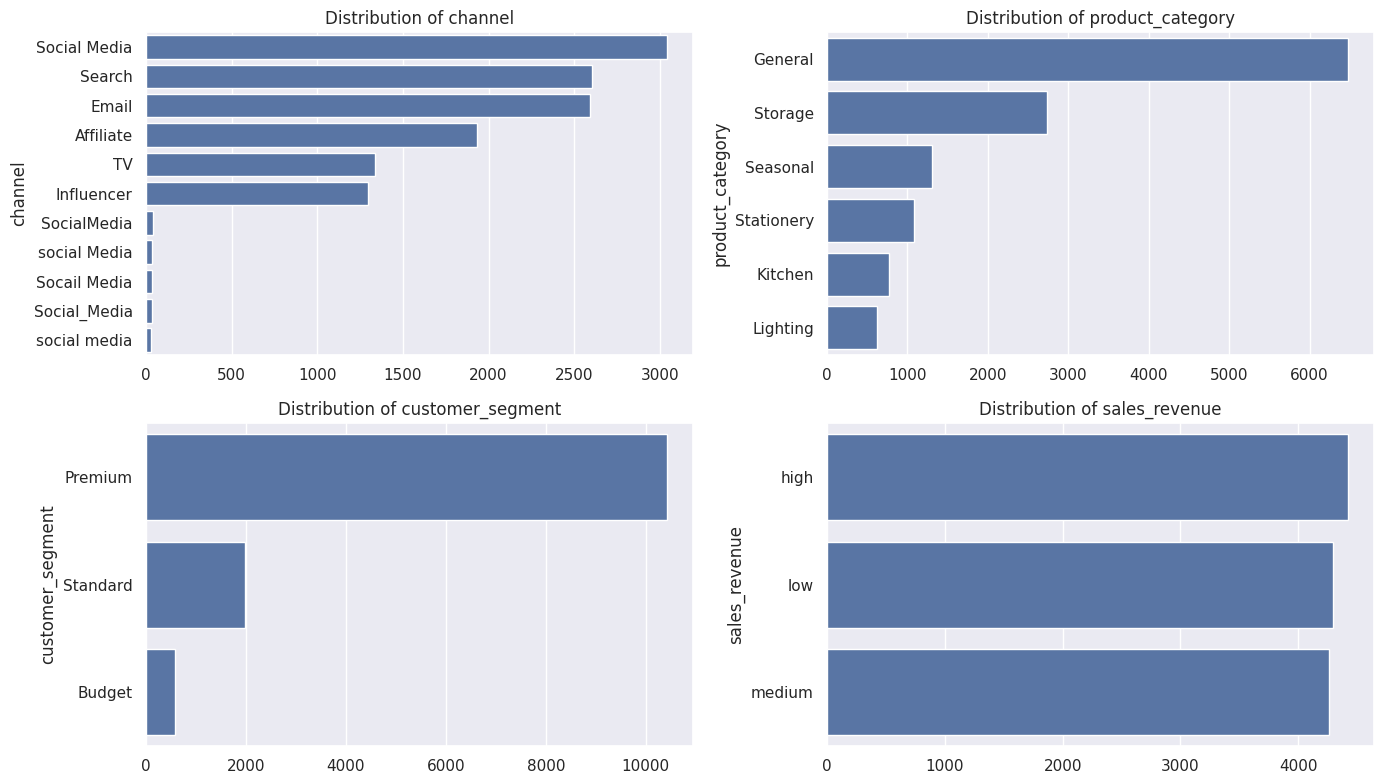

In [40]:
fig = plt.figure(1, (14, 8))

for i,cat in enumerate(df_cat.drop(['region'], axis=1).columns):
    ax = plt.subplot(2,2,i+1)
    sns.countplot(df_cat[cat], order=df_cat[cat].value_counts().index)
    ax.set_xlabel(None)
    ax.set_title(f'Distribution of {cat}')
    plt.tight_layout()

plt.show()

In [41]:
for i,cat in enumerate(df_cat.drop(['region'], axis=1).columns):
    val_counts = df_cat[cat].value_counts()
    dominant_frac = val_counts.iloc[0] / num_rows
    print(f'`{val_counts.index[0]}` alone contributes to {round(dominant_frac * 100, 2)}% of {cat}')

`Social Media` alone contributes to 23.41% of channel
`General` alone contributes to 49.89% of product_category
`Premium` alone contributes to 80.24% of customer_segment
`high` alone contributes to 34.06% of sales_revenue


In [42]:
df_cat.sales_revenue.value_counts()

,count
sales_revenue,
high,4422
low,4298
medium,4264


In [43]:
print(f'total unique categories in `region`: {df_cat.region.nunique()}')
print(f"\nunique categories in `region`:\n\n {df_cat.region.unique()}")

total unique categories in `region`: 9

unique categories in `region`:

 ['Nort' 'North' 'north' 'NORTH' 'Central' 'Norht' 'East' 'South' 'West']


/tmp/ipykernel_437/2869515996.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=75)


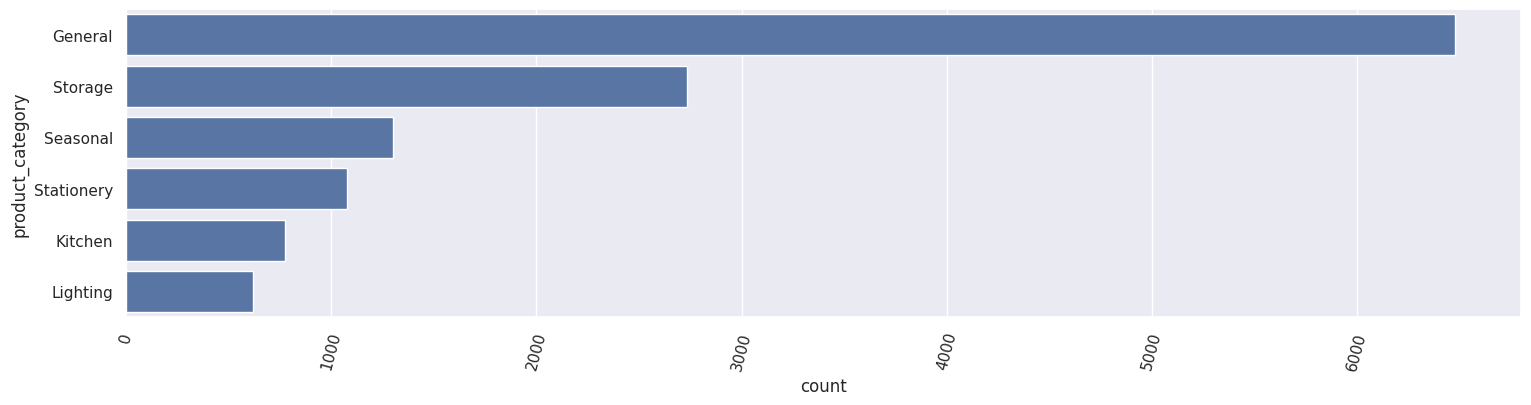

In [44]:
fig = plt.figure(1, (18, 4))

ax1 = plt.subplot(1,1,1)
sns.countplot(df_cat['product_category'], order=df_cat['product_category'].value_counts().index)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=75)

plt.show()

In [45]:
df_cat.product_category.value_counts()[:2]

,count
product_category,
General,6478
Storage,2736


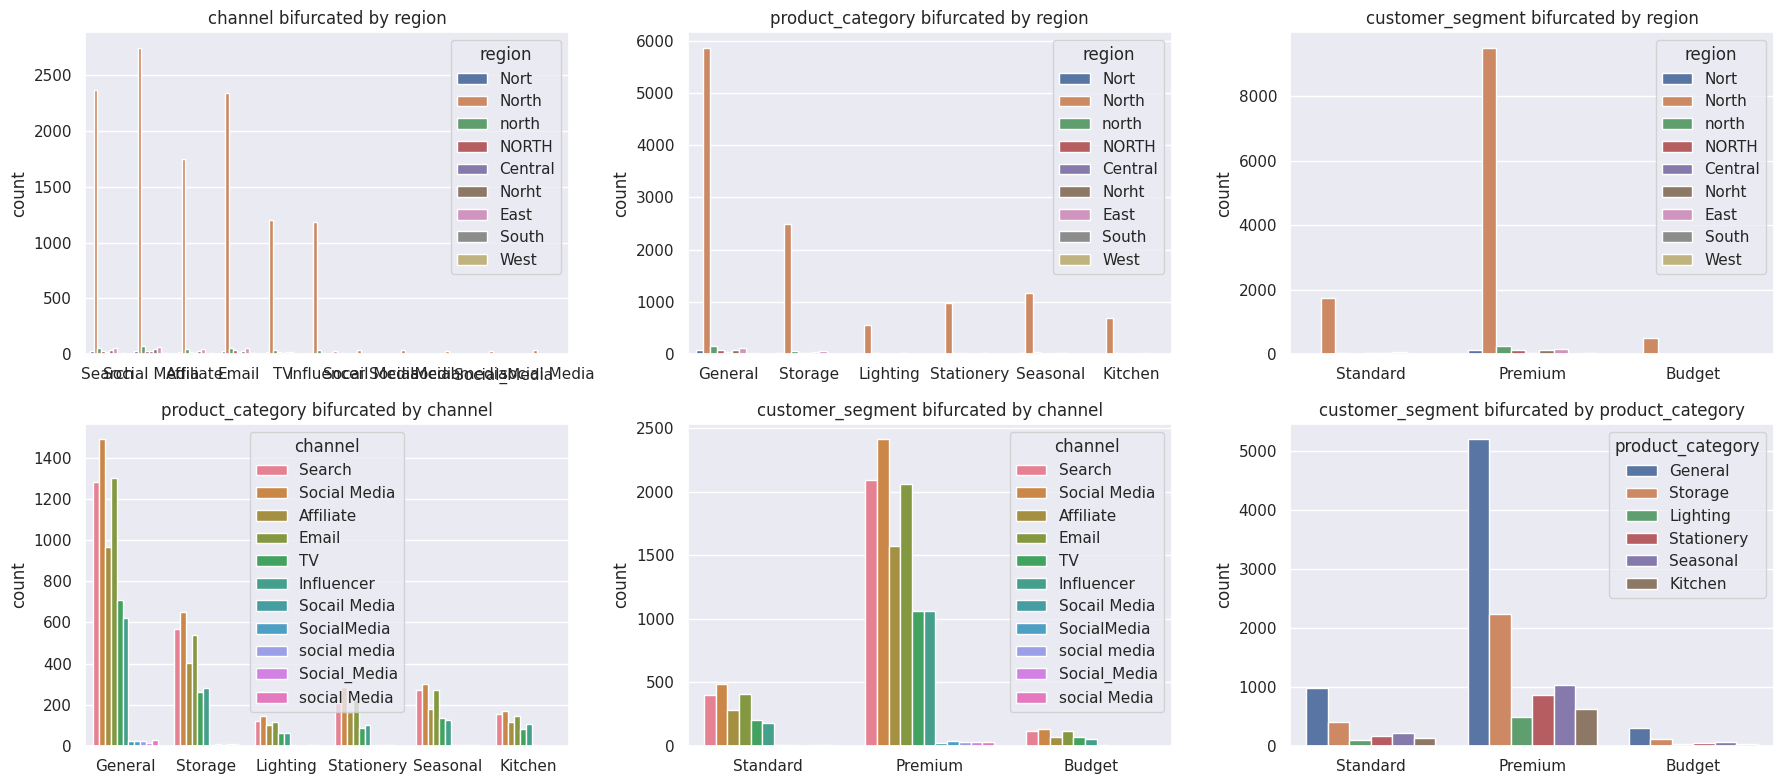

In [47]:
import itertools
combos = itertools.combinations(['region', 'channel', 'product_category', 'customer_segment'], 2)

fig = plt.figure(1, (18, 8))

i = 0
for pair in combos:

    i+=1
    ax = plt.subplot(2,3,i)
    sns.countplot(x=pair[1], hue=pair[0], data=df_cat)
    ax.set_xlabel(None)
    ax.set_title(f'{pair[1]} bifurcated by {pair[0]}')
    plt.tight_layout()

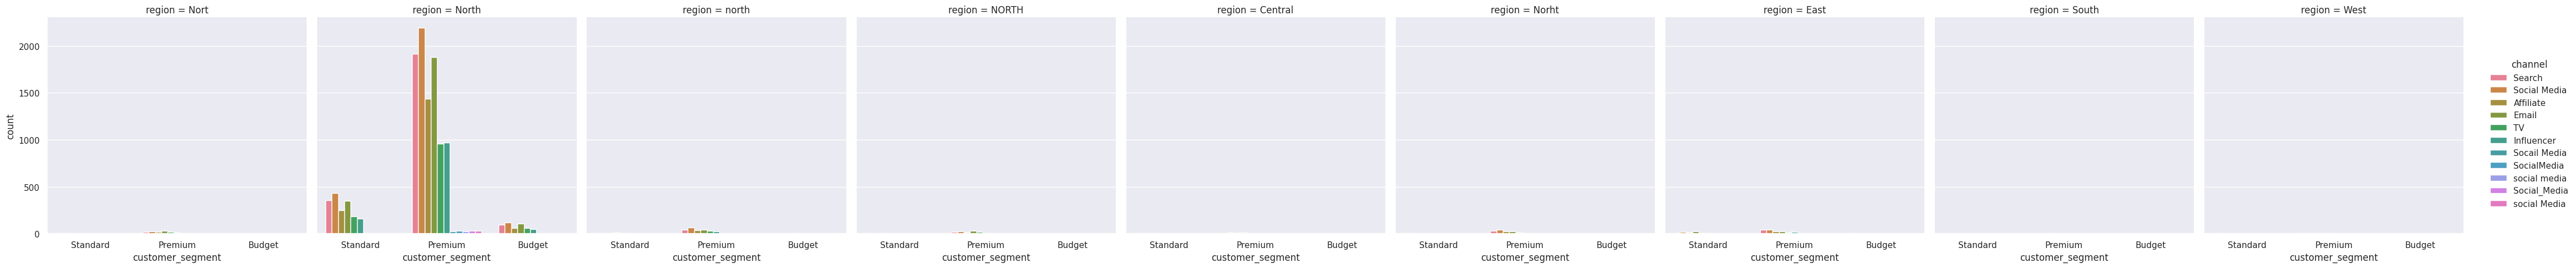

In [48]:
sns.catplot(x='customer_segment', hue='channel', col='region', data=df_cat, kind='count')
plt.show()

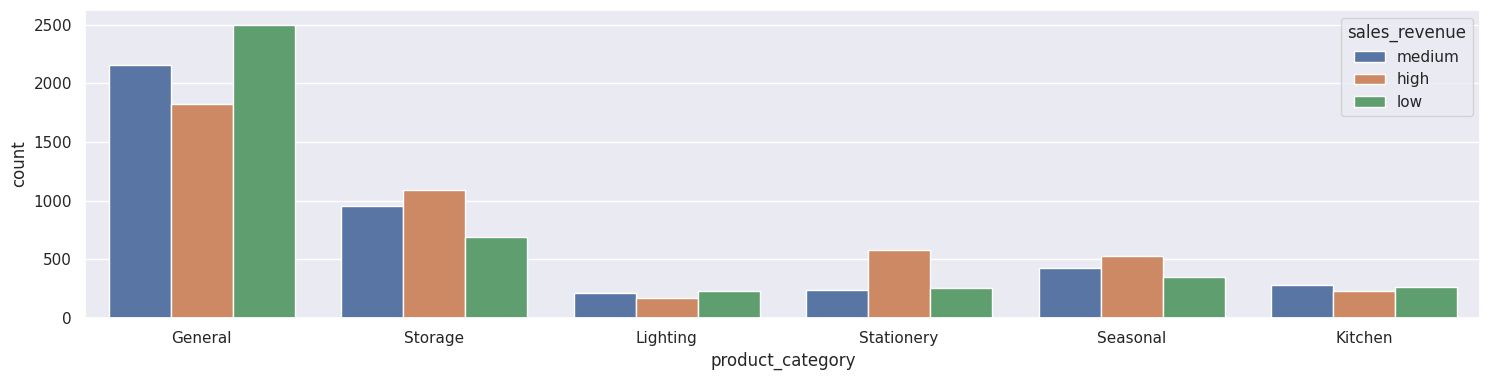

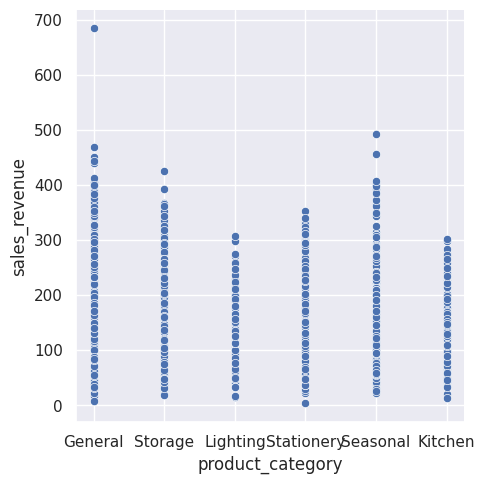

In [51]:
fig = plt.figure(1, (18,4))
sns.countplot(x='product_category', hue='sales_revenue', data=df_cat)
sns.relplot(x='product_category', y='sales_revenue', data=df)
plt.show()

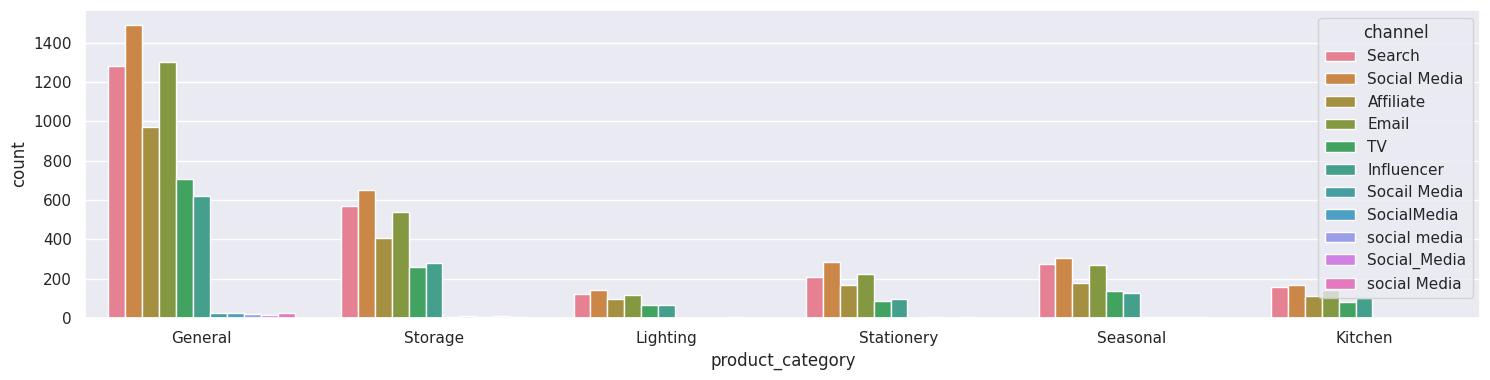

In [52]:
fig = plt.figure(1, (18,4))
sns.countplot(x='product_category', hue='channel', data=df_cat)
plt.show()

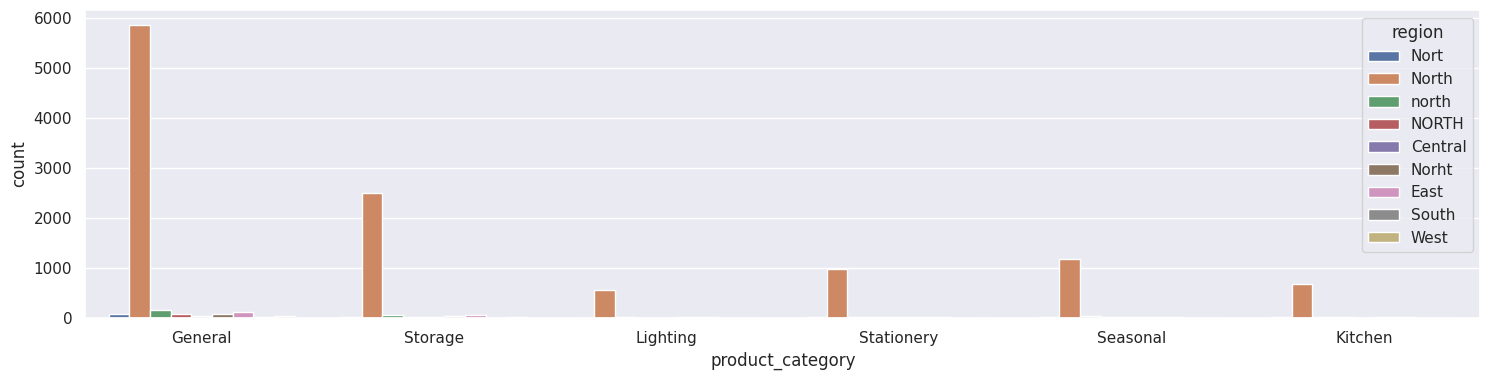

In [53]:
fig = plt.figure(1, (18,4))
sns.countplot(x='product_category', hue='region', data=df_cat)
plt.show()

In [ ]:
rows = len(nums)
cols = 4

fig = plt.figure(1, (18, rows*3))

i = 0

for col in nums:

    i += 1
    ax1 = plt.subplot(rows, cols,i)
#     ax1.hist(df[col], alpha=0.6)
    sns.distplot(df[col])
    ax1.set_xlabel(None)
    ax1.set_title(f'{col} distribution')
    plt.tight_layout()

    i += 1
    ax2 = plt.subplot(rows, cols,i)
    sns.violinplot(df[col])
    sns.swarmplot(df[col], alpha=0.6, color='k')
    ax2.set_xlabel(None)
    ax2.set_title(f'{col} swarm-violin plot')
    plt.tight_layout()

    i += 1
    ax3 = plt.subplot(rows, cols,i)
    sns.boxplot(df[col], orient='h', linewidth=2.5)
    ax3.set_xlabel(None)
    ax3.set_title(f'{col} box plot')
    plt.tight_layout()

    for col in nums:

    i += 1
    ax4 = plt.subplot(rows, cols,i)
    sns.distplot(df[col])
    ax4.set_xlabel(None)
    ax4.set_title(f'{col} distribution')
    plt.tight_layout()



In [ ]:
fig = plt.figure(1, (12, 4))
ax = plt.subplot(1,1,1)
sns.boxplot(x="variable", y="value", data=pd.melt(df))
plt.xlabel(None)
plt.ylabel(None)
plt.show()

In [ ]:
sns.pairplot(data=df, vars=nums, diag_kind='kde', hue='origin',
            plot_kws=dict(s=20, edgecolor="k", linewidth=0.1, alpha=0.5), diag_kws=dict(shade=True))
plt.show()